In [16]:
# using Pkg; Pkg.instantiate() # if error, resets config; delete Manifest.toml first, then run this code
# using Pkg; Pkg.add("Interpolations")
using Interpolations
using Revise
using Printf
using LinearAlgebra
using PyPlot
using FFTW
using MultiModeNoise
using DifferentialEquations
using NPZ

In [17]:
SK = zeros(1, 1, 1, 1)
SK[1, 1, 1, 1] = 2.6e-3

SK2 = [2.6e-3;;;;]

SK2

1×1×1×1 Array{Float64, 4}:
[:, :, 1, 1] =
 0.0026

In [18]:
# --- Physical Constants ---
const h = 6.626e-34    # Planck's constant (J*s)
const c = 3.0e8        # Speed of light (m/s)

# --- User-Defined Parameters (Update these with your values) ---
L = 2.5                # Fiber length (m)
core_radius = 2.5e-6   # core radius (m) ?? 
NA = 0.13              # Numerical Aperture
A = pi * core_radius^2 # Core area (m^2)
rho = 1e25             # Doping concentration (ions/m^3)
tau21 = 1.4e-3         # flourescence lifetime (s)

# Pump Parameters
lam_p = 976e-9         # Pump wavelength (m)
sigma_ap = 2.5e-24 #1.79e-24     # Absorption cross-section (m^2)  maybe change to Rp Photonics ??
sigma_ep = 2.5e-24     # Emission cross-section (m^2)
Pp0 = 0.6              # Initial Pump Power (W) - 600mW

V_p = 2 * pi * core_radius * NA / (lam_p)  # Normalized Frequency
w_p = core_radius * (0.616 + 1.66/(V_p^1.5) + 0.987/(V_p^6))

Gamma_p = 1-exp(-2*core_radius^2 / w_p^2)          # Overlap factor

# Signal Parameters
lam_s = 1030e-9        # Signal wavelength (m)
sigma_as = 0.055e-24    # Absorption cross-section (m^2)  From Nufern 0.055
sigma_es = 0.66e-24     # Emission cross-section (m^2)  0.76
Ps0 = 0.01             # Initial Signal Power (W)  - 20mW

V_s = 2 * pi * core_radius * NA / (lam_s)  # Normalized Frequency
w_s = core_radius * (0.616 + 1.66/(V_s^1.5) + 0.987/(V_s^6))

Gamma_s = 1-exp(-2*core_radius^2 / w_s^2)          # Overlap factor

# Derived Frequencies
nu_p = c / lam_p
nu_s = c / lam_s

println(Gamma_p)
println(Gamma_s)

0.764363987425803
0.7351579934623428


# Adding some spectral stuff

1030.9278350515465


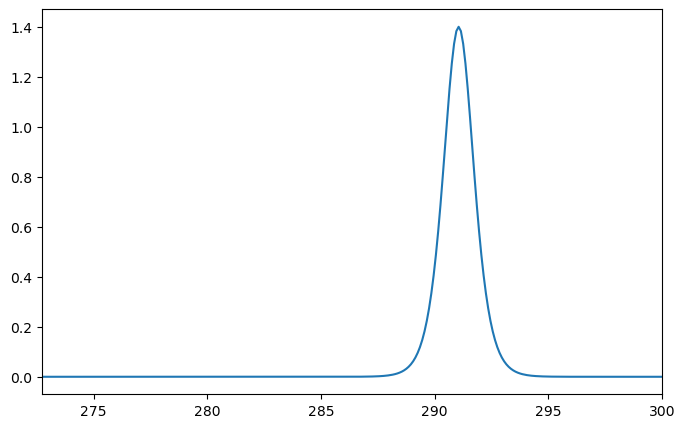

In [19]:
# Now we want to create a proper power spectrum or something

λ0 = 1030e-9 # m
M = 1 # number of sp modes
Nt = 2^12 # 2^10, frequency bins
time_window = 10 # ps, range of pulse
β_order = 2; # mode order: 0, 1, 2, ...

# simulation params
sim = MultiModeNoise.get_disp_sim_params(λ0, M, Nt, time_window, β_order); # sim = dictionary of params from inputs from helpers.jl

P_cont = 0.02 # W
pulse_fwhm = 200e-15 # s
pulse_rep_rate = 80e6 # Hz

ut0, uω0 = MultiModeNoise.get_initial_state([1], P_cont, pulse_fwhm, pulse_rep_rate, "sech_sq", sim); # initial state [Nt x M]

println(c/291 * 1e-12 * 1e9)  # quick wavelength check

# Create a plot in frequency
fig = figure(figsize=(8, 5))
# plot(sim["ts"]*1e15,ut0)
plot(sim["fs"], abs2.(fftshift(uω0)))
xlim(c/1100 * 1e-12 * 1e9, c/1000 * 1e-12 * 1e9)
fig

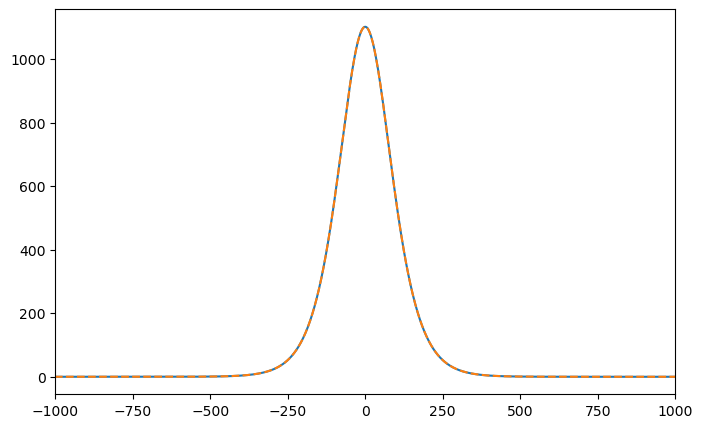

In [20]:
# Create a plot in time
fig = figure(figsize=(8, 5))
# plot(sim["ts"]*1e15,ut0)
plot(sim["ts"]*1e15, abs2.(ut0))
plot(sim["ts"]*1e15, abs2.(fft(uω0, 1)), "--")  # this is the proper power
xlim(-1000, 1000)
fig

In [21]:
# Test to get the average power back from a pulse
pulse_energy = sum(abs2.(ut0)) * (sim["Δt"] * 1e-12)  # it is in picoseconds
P_avg = pulse_energy * pulse_rep_rate
print(P_avg, "   ", pulse_energy)

0.02000054461905032   2.50006807738129e-10

Avg Energy: 2.5000680773812896e-10
Avg Power: 0.020000544619050317


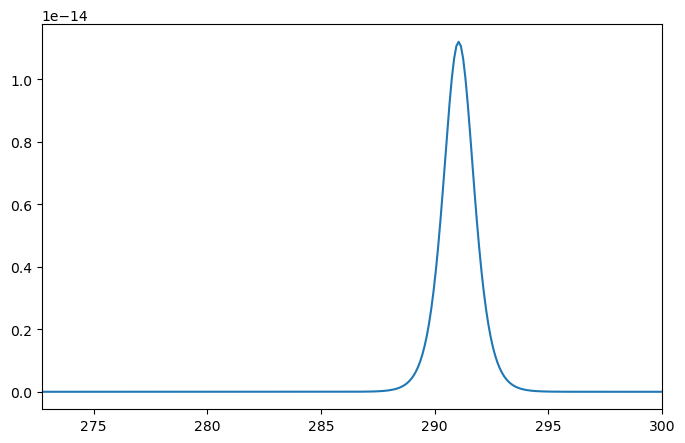

In [22]:
# Get the Ps_dB
dt = sim["Δt"] * 1e-12  #s
df = 1 / (sim["Nt"] * dt)  #Hz


# Michael treats freq space as the inverse transform?? So ut0 -> uw0 is always divided by Nt. NOT THE PROPER DEFINITION
uw0_s = uω0 .* Nt .* dt  
ESD_f = abs2.(uw0_s)  # energy spectral density
println("Avg Energy: ", sum(ESD_f) * df)
println("Avg Power: ", sum(ESD_f) * df * pulse_rep_rate)

# Create a plot in frequency
fig = figure(figsize=(8, 5))
# plot(sim["ts"]*1e15,ut0)
plot(sim["fs"], fftshift(ESD_f) * pulse_rep_rate)
xlim(c/1100 * 1e-12 * 1e9, c/1000 * 1e-12 * 1e9)
fig


In [23]:
# Extract Yb_emission and Absorption from npz files
absorption_values = npzread("Yb_absorption.npz")
emission_values = npzread("Yb_emission.npz")

x_raw_abs = absorption_values["wavelength"] * 1e-9
y_raw_abs = absorption_values["intensity"] * 1e-27
itp_abs = linear_interpolation(x_raw_abs, y_raw_abs, extrapolation_bc=Flat())

x_raw_em = emission_values["wavelength"] * 1e-9
y_raw_em = emission_values["intensity"] * 1e-27
itp_em = linear_interpolation(x_raw_em, y_raw_em, extrapolation_bc=Flat())



# Wavelength array
λ_target = c ./ (sim["fs"] * 1e12)
sigma_as_vec = itp_abs.(λ_target);
sigma_es_vec = itp_em.(λ_target)

println(c/297 * 1e-12 * 1e9)  # quick wavelength check

# Create a plot in frequency
fig = figure(figsize=(8, 5))
# plot(sim["ts"]*1e15,ut0)
plot(sim["fs"], sigma_as_vec * 1e24)
plot(sim["fs"], sigma_es_vec * 1e24)
xlim(c/1100 * 1e-12 * 1e9, c/1000 * 1e-12 * 1e9)
# ylim(0, 1000)
fig

SystemError: SystemError: opening file "Yb_absorption.npz": No such file or directory

In [24]:
Ps0_vec = fftshift(ESD_f) * pulse_rep_rate

nu_s_vec = sim["fs"] * 1e12

println(sum(Ps0_vec) * df)

function yb_spectral_amplifier!(du, u, p, z)
    # p = (Gamma_p, Gamma_s, sigma_ap, sigma_ep, sigma_as_vec, sigma_es_vec, h, nu_p, nu_s_vec, A, tau21, rho)
    Pp = u[1]
    Ps_vec = @view u[2:end] # Use a view for performance
    
    # 1. Pump Rates (Scalars) 
    R12 = (Gamma_p * sigma_ap * Pp) / (h * nu_p * A)
    R21 = (Gamma_p * sigma_ep * Pp) / (h * nu_p * A)
    
    # 2. Signal Rates (Summed across the spectrum)
    # W = Σ (Γs * σ * Ps_i) / (h * ν_i * A)
    W12 = sum((Gamma_s .* sigma_as_vec .* Ps_vec .* df) ./ (h .* nu_s_vec .* A))  # PSD * df tells you the actual power in each frequency. Otherwise its W/Hz
    W21 = sum((Gamma_s .* sigma_es_vec .* Ps_vec .* df) ./ (h .* nu_s_vec .* A))
    
    # 3. Population Inversion (N2 is still a single value at position z)
    denom = R12 + R21 + W12 + W21 + (1 / tau21)
    n2 = (R12 + W12) / denom
    n1 = 1.0 - n2
    
    # 4. Evolution Equations
    # Pump evolution
    du[1] = Gamma_p * (sigma_ep * n2 - sigma_ap * n1) * rho * Pp
    
    # Signal evolution (Element-wise for the whole spectrum)
    @. du[2:end] = Gamma_s * (sigma_es_vec * n2 - sigma_as_vec * n1) * rho * Ps_vec
end

# --- Solver Execution ---
u0 = vcat(Pp0, Ps0_vec)         # Initial conditions [Pump, Signal]
z_save = range(0.0, L, 100)
z_span = (0.0, L)       # Fiber span
prob = ODEProblem(yb_spectral_amplifier!, u0, z_span, saveat=z_save)
sol = solve(prob, RK4(), reltol=1e-8, abstol=1e-8);

println(summary(Ps0_vec))
println(summary(u0))

0.020000544619050317
4096×1 Matrix{Float64}
4097×1 Matrix{Float64}


100-element Vector{Float64}
4096×100 Matrix{Float64}


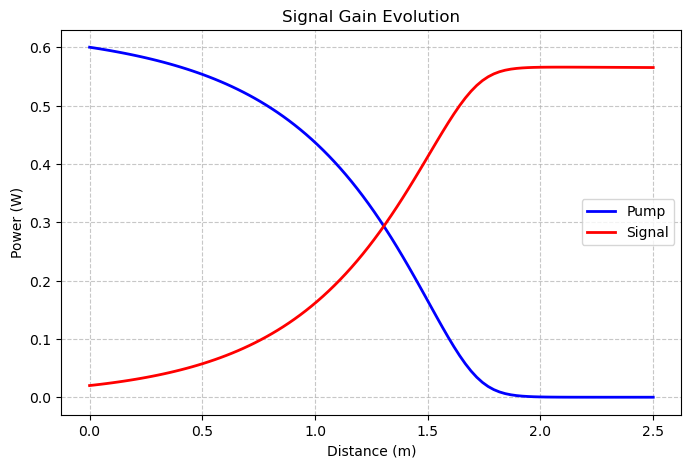

In [25]:
z    = sol.t          # Fiber positions
Pp_z = sol[1, :]      # Pump power along z
Ps_fz = sol[2:end, :]; # Signal spectrum matrix (Frequencies x Z-steps)
Ps_z = vec(sum(Ps_fz, dims=1)) .* df

println(summary(Pp_z))
println(summary(Ps_fz))

Ps_start = Ps_fz[:, 1]
Ps_end = Ps_fz[:, end]

# 3. Create the plot
fig = figure(figsize=(8, 5))

# Plot Signal and PUmp power over length
# plot(z_save, Ps_raw, label="Signal", color="red", linewidth=2)
plot(z_save, Pp_z, label="Pump", color="blue", linewidth=2)
plot(z_save, Ps_z, label="Signal", color="red", linewidth=2)

# 4. Formatting
title("Signal Gain Evolution")
xlabel("Distance (m)")
ylabel("Power (W)") # Changed from Power (W) to Gain (dB)
# ylim(-10, 40)
grid(true, linestyle="--", alpha=0.7)
legend()

fig

0.020000544619050317
0.5651772916598068


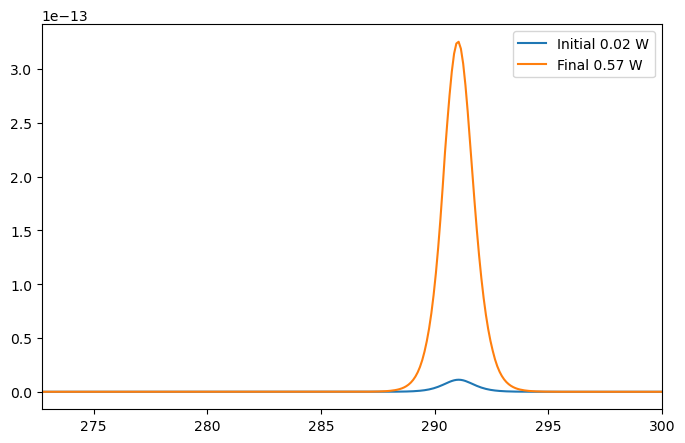

In [26]:
# 3. Create the plot
fig = figure(figsize=(8, 5))

println(sum(Ps_start) * df)
println(sum(Ps_end) * df)

# Plot Signal and PUmp power over length
# plot(z_save, Ps_raw, label="Signal", color="red", linewidth=2)
plot(sim["fs"], Ps_start, label="Initial $(round((sum(Ps_start) * df), digits=2)) W")
plot(sim["fs"], Ps_end, label="Final $(round((sum(Ps_end) * df), digits=2)) W")
xlim(c/1100 * 1e-12 * 1e9, c/1000 * 1e-12 * 1e9)
legend()
fig

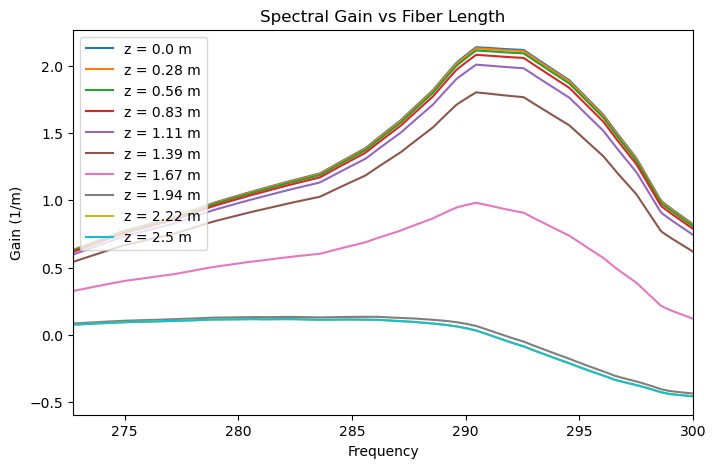

In [27]:
# --- Gain spectrum helper ---
function gain_spectrum(u)
    Pp = u[1]
    Ps = @view u[2:end]

    R12 = (Gamma_p * sigma_ap * Pp) / (h * nu_p * A)
    R21 = (Gamma_p * sigma_ep * Pp) / (h * nu_p * A)

    W12 = sum((Gamma_s .* sigma_as_vec .* Ps .* df) ./ (h .* nu_s_vec .* A))
    W21 = sum((Gamma_s .* sigma_es_vec .* Ps .* df) ./ (h .* nu_s_vec .* A))

    n2 = (R12 + W12) / (R12 + R21 + W12 + W21 + 1/tau21)
    n1 = 1.0 - n2

    Gamma_s .* (sigma_es_vec .* n2 .- sigma_as_vec .* n1) .* rho
end


# --- Pick ~10 z slices ---
Nslices = 10
idx = round.(Int, range(1, length(sol.u), length=Nslices))


# --- Plot ---
fig = figure(figsize=(8,5))

for i in idx
    g = gain_spectrum(sol.u[i])

    plot(
        sim["fs"],          # or wavelength if you prefer
        g,
        label = "z = $(round(z_save[i], digits=2)) m"
    )
end

xlim(c/1100 * 1e-12 * 1e9, c/1000 * 1e-12 * 1e9)
xlabel("Frequency")
ylabel("Gain (1/m)")
title("Spectral Gain vs Fiber Length")
legend(loc="upper left")
fig

In [28]:
# # --- The ODE System ---
# function yb_amplifier!(du, u, p, z)
#     Pp, Ps = u
    
#     # 1. Calculate Transition Rates
#     # Rij = Γp * σ * Pp / (h * νp * A)
#     R12 = (Gamma_p * sigma_ap * Pp) / (h * nu_p * A)
#     R21 = (Gamma_p * sigma_ep * Pp) / (h * nu_p * A)
    
#     # Wij = Γs * σ * Ps / (h * νs * A)
#     W12 = (Gamma_s * sigma_as * Ps) / (h * nu_s * A)
#     W21 = (Gamma_s * sigma_es * Ps) / (h * nu_s * A)
    
#     # 2. Calculate Normalized Population Inversion N2(z)
#     denom = R12 + R21 + W12 + W21 + (1 / tau21)
#     n2 = (R12 + W12) / denom
#     n1 = 1.0 - n2  # Normalized total population N1 + N2 = 1
    
#     # 3. Power Evolution Equations
#     # dPp/dz = Γp * [σe*N2 - σa*N1] * ρ * Pp
#     du[1] = Gamma_p * (sigma_ep * n2 - sigma_ap * n1) * rho * Pp
    
#     # dPs/dz = Γs * [σe*N2 - σa*N1] * ρ * Ps
#     du[2] = Gamma_s * (sigma_es * n2 - sigma_as * n1) * rho * Ps
# end

# # --- Solver Execution ---
# u0 = [Pp0, Ps0]         # Initial conditions [Pump, Signal]
# z_save = range(0.0, L, 100)
# z_span = (0.0, L)       # Fiber span
# prob = ODEProblem(yb_amplifier!, u0, z_span, saveat=z_save)
# sol = solve(prob, RK4(), reltol=1e-8, abstol=1e-8);

In [29]:
# # 1. Extract data from the solution
# z_vals = sol.t              
# Ps_raw = [u[2] for u in sol.u] # Signal powers in Watts
# Pp_raw = [u[1] for u in sol.u]  # Pump powers in Watts
# # 2. Convert Signal to Gain (dB)
# # Gain (dB) = 10 * log10(P_z / P_initial)
# # Ps_dB = 10 .* log10.(Ps_raw ./ signal_power) 

# # 3. Create the plot
# fig = figure(figsize=(8, 5))

# # Plot Signal and PUmp power over length
# plot(z_save, Ps_raw, label="Signal", color="red", linewidth=2)
# plot(z_save, Pp_raw, label="Pump", color="blue", linewidth=2)

# # 4. Formatting
# title("Signal Gain Evolution")
# xlabel("Distance (m)")
# ylabel("Power (W)") # Changed from Power (W) to Gain (dB)
# # ylim(-10, 40)
# grid(true, linestyle="--", alpha=0.7)
# legend()

# fig